<a href="https://colab.research.google.com/github/Nandhini-29-2007/Air-quality-inspector/blob/main/Air_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 2000

PM25 = np.random.uniform(5, 250, n)
PM10 = PM25 + np.random.uniform(10, 100, n)
NO2 = np.random.uniform(5, 100, n)
SO2 = np.random.uniform(2, 60, n)
CO = np.random.uniform(0.1, 3.0, n)
O3 = np.random.uniform(10, 150, n)

Temperature = np.random.uniform(15, 40, n)
Humidity = np.random.uniform(30, 95, n)
Wind_Speed = np.random.uniform(0.5, 10, n)

AQI = (
    0.45 * PM25
    + 0.20 * PM10
    + 0.10 * NO2
    + 0.05 * SO2
    + 5 * CO
    + 0.05 * O3
    - 0.2 * Wind_Speed
    + np.random.normal(0, 8, n)
)

AQI = np.maximum(AQI, 0)

df = pd.DataFrame({
    "PM2.5": PM25,
    "PM10": PM10,
    "NO2": NO2,
    "SO2": SO2,
    "CO": CO,
    "O3": O3,
    "Temperature": Temperature,
    "Humidity": Humidity,
    "Wind Speed": Wind_Speed,
    "AQI": AQI
})

df.head()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed,AQI
0,96.762329,130.315841,59.339608,39.598903,2.188777,62.309715,31.357658,34.756381,0.541815,82.356841
1,237.925005,270.153097,81.516071,11.998409,2.093121,56.607693,17.000814,35.816095,0.503137,196.651532
2,184.338516,275.901428,77.215288,52.598885,0.377687,34.661548,21.058245,72.378291,4.986503,165.543590
3,151.671329,184.130487,19.620491,37.560742,2.775460,95.017334,34.341984,61.651146,0.778290,125.519753
4,43.224567,77.700042,19.178700,11.117825,1.748569,76.727382,28.217146,81.376991,9.758059,45.126846


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Number of rows: 2000
Number of columns: 10

Column names:
Index(['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Temperature', 'Humidity',
       'Wind Speed', 'AQI'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PM2.5        2000 non-null   float64
 1   PM10         2000 non-null   float64
 2   NO2          2000 non-null   float64
 3   SO2          2000 non-null   float64
 4   CO           2000 non-null   float64
 5   O3           2000 non-null   float64
 6   Temperature  2000 non-null   float64
 7   Humidity     2000 non-null   float64
 8   Wind Speed   2000 non-null   float64
 9   AQI          2000 non-null   float64
dtypes: float64(10)
memory usage: 156.4 KB


In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
PM2.5          0
PM10           0
NO2            0
SO2            0
CO             0
O3             0
Temperature    0
Humidity       0
Wind Speed     0
AQI            0
dtype: int64


In [5]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [6]:
df = df.drop_duplicates()

print("Duplicates removed.")

Duplicates removed.


In [7]:
df.describe()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed,AQI
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,127.166048,181.841182,52.147066,30.294704,1.525773,80.766030,27.387989,62.366233,5.351319,111.067512
std,71.591646,76.250777,27.354400,16.664231,0.818294,40.779190,7.270367,18.869319,2.704235,47.816916
min,5.788475,22.707157,5.002918,2.013978,0.100153,10.022084,15.030090,30.020133,0.502398,12.388209
25%,63.321386,118.452403,28.458838,15.881149,0.834461,45.401733,20.938611,45.901747,3.097473,69.323212
50%,129.301061,184.009767,51.693521,30.083531,1.511441,80.450643,27.197017,62.252911,5.458627,111.249909
75%,188.916314,244.461868,75.285919,44.753750,2.216083,116.781827,33.823800,79.350999,7.596524,151.887394
max,249.930830,341.993269,99.938279,59.968720,2.998565,149.954249,39.971121,94.995114,9.991921,211.131488


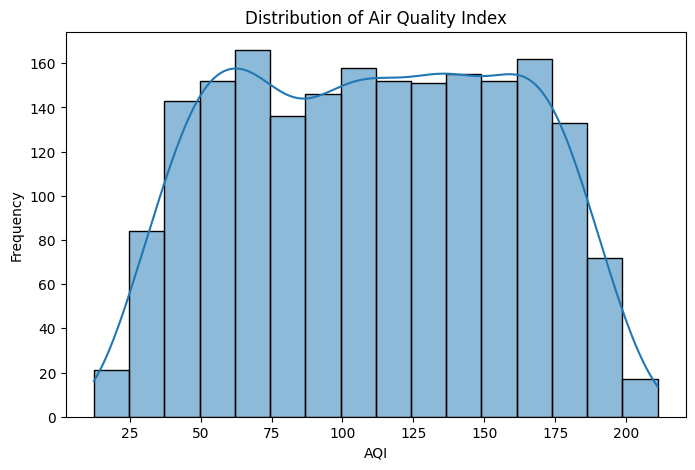

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["AQI"], kde=True)

plt.title("Distribution of Air Quality Index")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

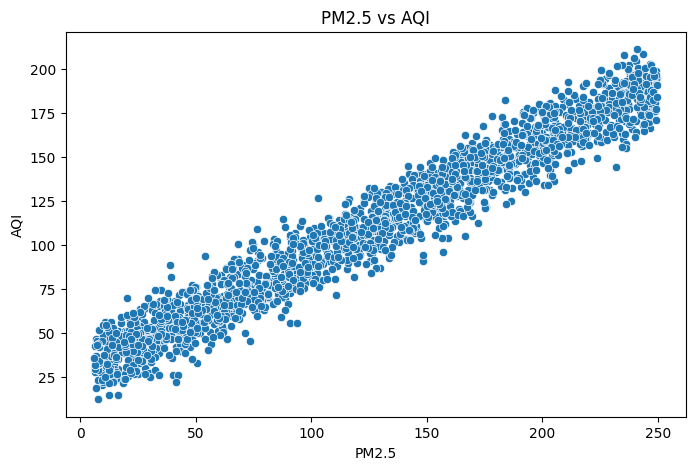

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="PM2.5",
    y="AQI"
)

plt.title("PM2.5 vs AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")

plt.show()

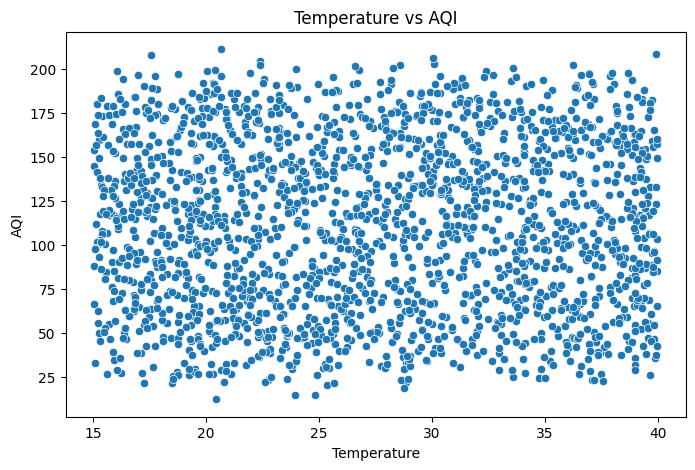

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Temperature",
    y="AQI"
)

plt.title("Temperature vs AQI")
plt.xlabel("Temperature")
plt.ylabel("AQI")

plt.show()

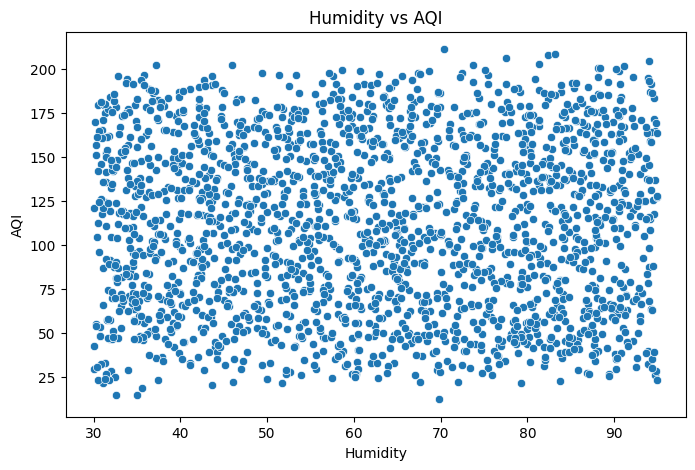

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Humidity",
    y="AQI"
)

plt.title("Humidity vs AQI")
plt.xlabel("Humidity")
plt.ylabel("AQI")

plt.show()

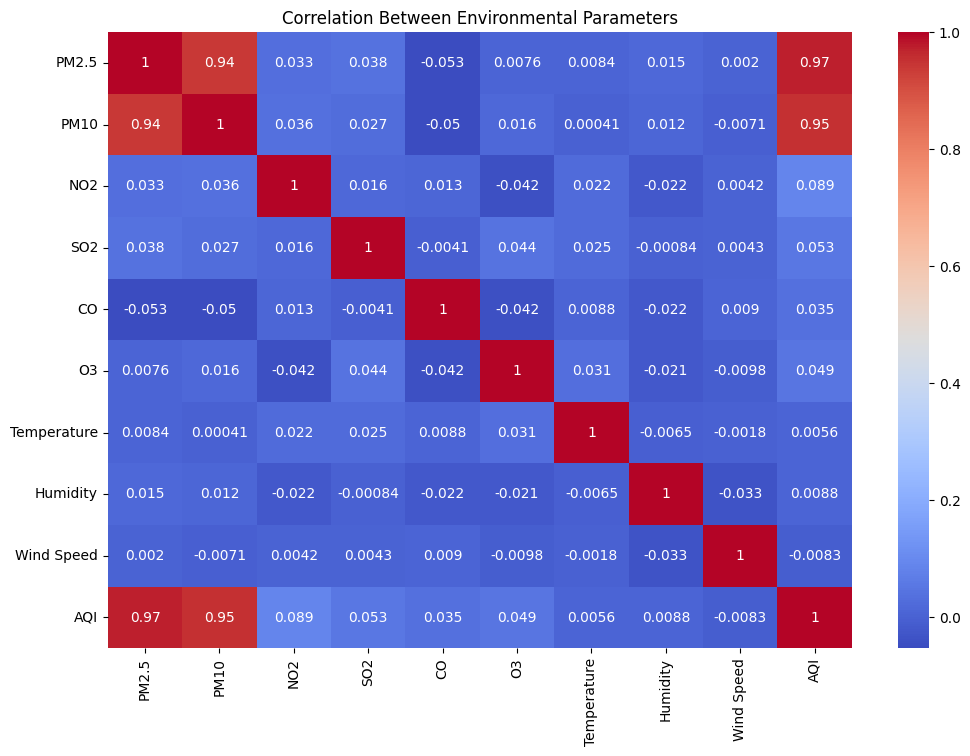

In [12]:
plt.figure(figsize=(12,8))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Environmental Parameters")

plt.show()

In [13]:
def categorize_aqi(aqi):

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Satisfactory"

    elif aqi <= 200:
        return "Moderate"

    elif aqi <= 300:
        return "Poor"

    elif aqi <= 400:
        return "Very Poor"

    else:
        return "Severe"


df["AQI_Category"] = df["AQI"].apply(categorize_aqi)

df.head()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed,AQI,AQI_Category
0,96.762329,130.315841,59.339608,39.598903,2.188777,62.309715,31.357658,34.756381,0.541815,82.356841,Satisfactory
1,237.925005,270.153097,81.516071,11.998409,2.093121,56.607693,17.000814,35.816095,0.503137,196.651532,Moderate
2,184.338516,275.901428,77.215288,52.598885,0.377687,34.661548,21.058245,72.378291,4.986503,165.543590,Moderate
3,151.671329,184.130487,19.620491,37.560742,2.775460,95.017334,34.341984,61.651146,0.778290,125.519753,Moderate
4,43.224567,77.700042,19.178700,11.117825,1.748569,76.727382,28.217146,81.376991,9.758059,45.126846,Good


In [14]:
print(df["AQI_Category"].value_counts())

AQI_Category
Moderate        1135
Satisfactory     601
Good             252
Poor              12
Name: count, dtype: int64


In [15]:
features = [
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "O3",
    "Temperature",
    "Humidity",
    "Wind Speed"
]

X = df[features]

y = df["AQI"]

print("Input features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input features:
        PM2.5        PM10        NO2        SO2        CO         O3  \
0   96.762329  130.315841  59.339608  39.598903  2.188777  62.309715   
1  237.925005  270.153097  81.516071  11.998409  2.093121  56.607693   
2  184.338516  275.901428  77.215288  52.598885  0.377687  34.661548   
3  151.671329  184.130487  19.620491  37.560742  2.775460  95.017334   
4   43.224567   77.700042  19.178700  11.117825  1.748569  76.727382   

   Temperature   Humidity  Wind Speed  
0    31.357658  34.756381    0.541815  
1    17.000814  35.816095    0.503137  
2    21.058245  72.378291    4.986503  
3    34.341984  61.651146    0.778290  
4    28.217146  81.376991    9.758059  

Target:
0     82.356841
1    196.651532
2    165.543590
3    125.519753
4     45.126846
Name: AQI, dtype: float64


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1600, 9)
Testing data: (400, 9)


In [17]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")


Linear Regression model trained successfully!


In [18]:
linear_predictions = linear_model.predict(X_test)

print("Actual AQI:")
print(y_test.head())

print("\nPredicted AQI:")
print(linear_predictions[:5])

Actual AQI:
1860    159.911536
353      73.056049
1333    196.333369
905     149.218879
1289     28.423453
Name: AQI, dtype: float64

Predicted AQI:
[168.10491665  71.40579433 188.49132683 163.20184571  39.40593963]


In [19]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("--------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R2  :", linear_r2)

Linear Regression Results
--------------------------
MAE : 6.610517131598561
RMSE: 8.211985281145047
R2  : 0.9698599243165019


In [20]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [21]:
rf_predictions = rf_model.predict(X_test)

print("Predicted AQI:")
print(rf_predictions[:10])

Predicted AQI:
[166.56220686  67.00313488 183.69482636 164.64444105  35.22229496
  45.22008433  62.96062186 135.03076975 116.97119805  61.72787972]


In [22]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest Results
---------------------
MAE : 7.485805188872043
RMSE: 9.367812080859075
R2  : 0.9607784859722401


In [23]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],

    "MAE": [
        linear_mae,
        rf_mae
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse
    ],

    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,6.610517,8.211985,0.969860
1,Random Forest,7.485805,9.367812,0.960778


In [24]:
X = df[features]

y_category = df["AQI_Category"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X,
    y_category,
    test_size=0.2,
    random_state=42,
    stratify=y_category
)

print("Classification data prepared!")

Classification data prepared!


In [25]:
classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

classifier.fit(
    X_train_c,
    y_train_c
)

print("Classification model trained successfully!")

Classification model trained successfully!


In [26]:
category_predictions = classifier.predict(X_test_c)

print(category_predictions[:10])

['Moderate' 'Moderate' 'Satisfactory' 'Moderate' 'Moderate' 'Moderate'
 'Moderate' 'Satisfactory' 'Moderate' 'Good']


In [27]:
accuracy = accuracy_score(
    y_test_c,
    category_predictions
)

print("Classification Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Classification Accuracy: 0.9125
Accuracy Percentage: 91.25 %


In [28]:
print(
    classification_report(
        y_test_c,
        category_predictions
    )
)

              precision    recall  f1-score   support

        Good       0.80      0.86      0.83        51
    Moderate       0.94      0.98      0.96       227
        Poor       0.00      0.00      0.00         2
Satisfactory       0.90      0.82      0.86       120

    accuracy                           0.91       400
   macro avg       0.66      0.67      0.66       400
weighted avg       0.91      0.91      0.91       400



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


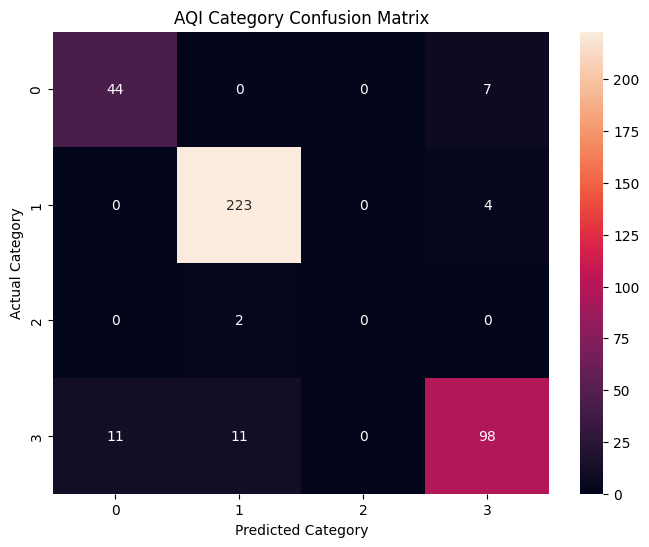

In [29]:
cm = confusion_matrix(
    y_test_c,
    category_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("AQI Category Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.show()

In [30]:
joblib.dump(
    rf_model,
    "air_quality_regression.pkl"
)

joblib.dump(
    classifier,
    "air_quality_classifier.pkl"
)

print("Models saved successfully!")

Models saved successfully!


In [34]:
import zipfile

with zipfile.ZipFile("air_quality_models.zip", "w") as zipf:
    zipf.write("air_quality_regression.pkl")
    zipf.write("air_quality_classifier.pkl")

print("ZIP file created successfully!")

ZIP file created successfully!


In [36]:
from google.colab import files

files.download("air_quality_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>